<a href="https://colab.research.google.com/github/SimbakNetmind/curso-nlp-yt/blob/02-Similitud-de-Textos-y-Representaciones-Vectoriale/11_Crear_un_Recomendador_de_Pel%C3%ADculas_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

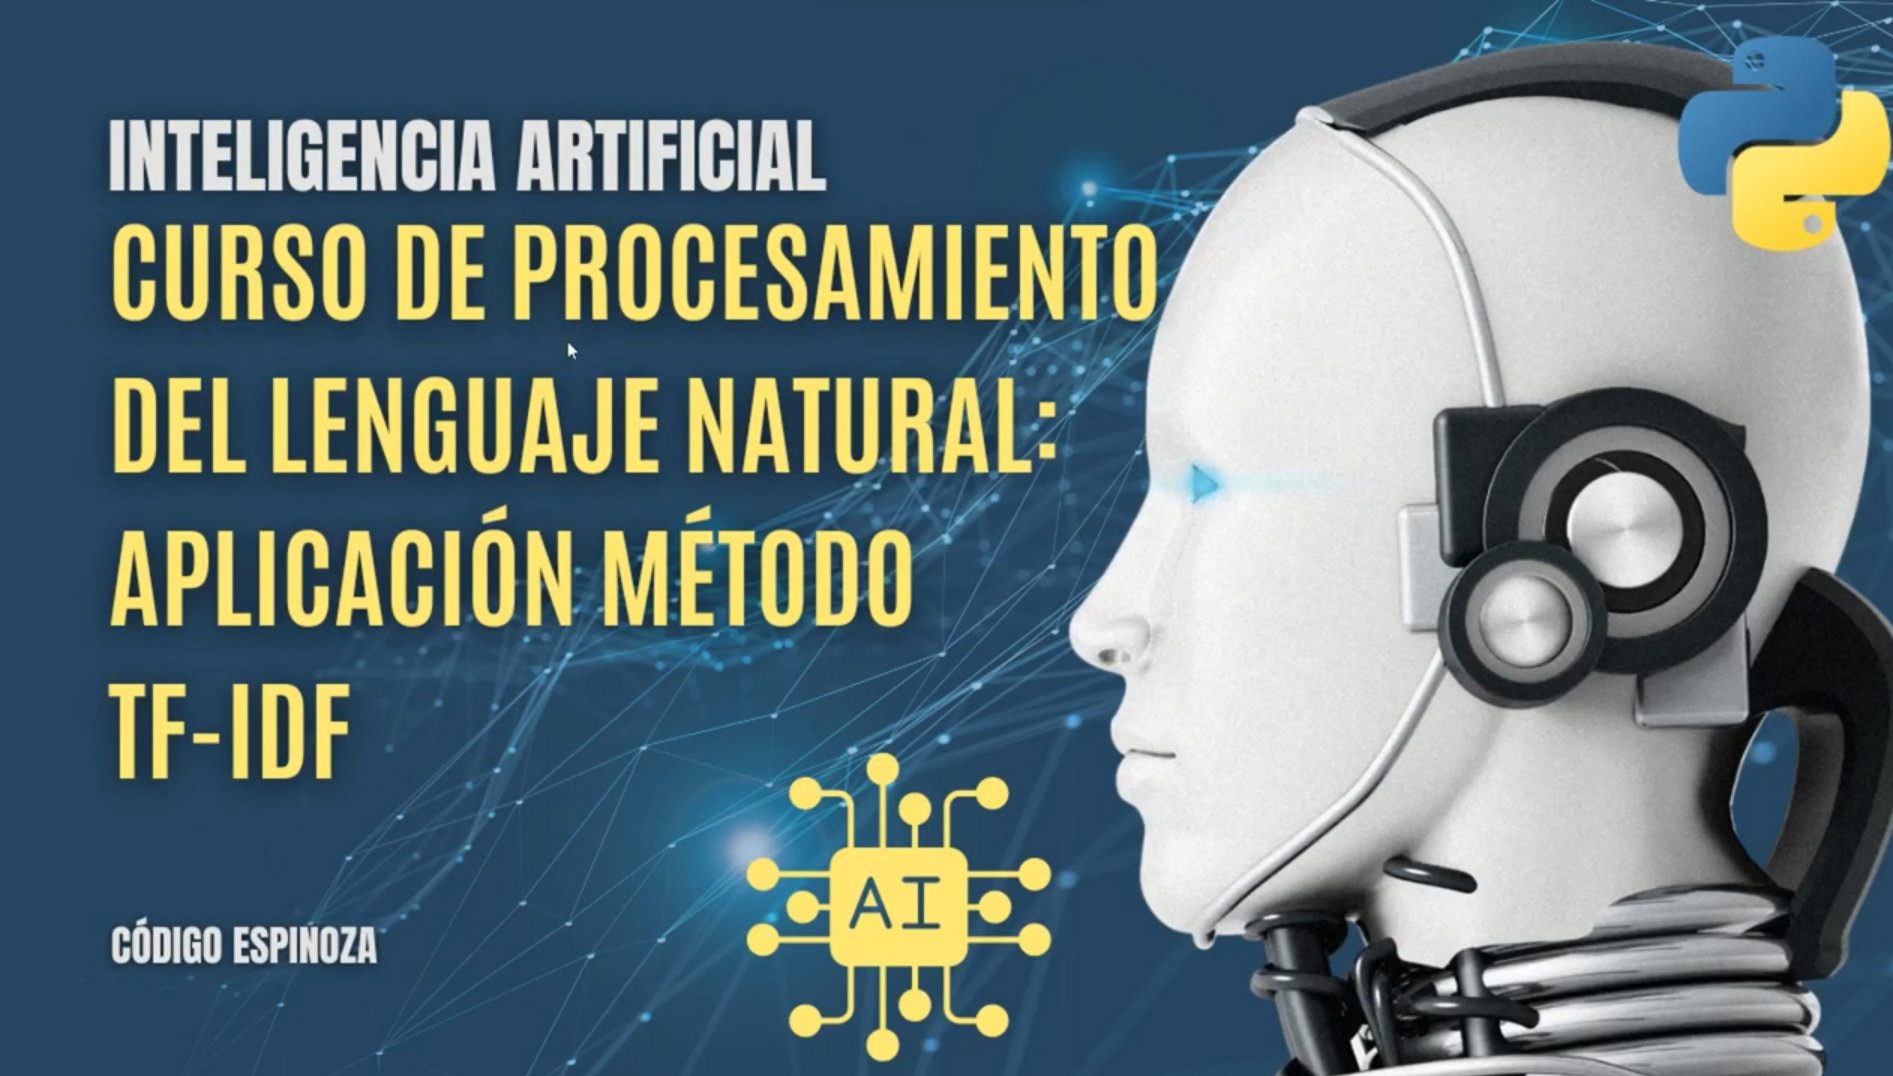

# 📌***Crear un Recomendador de Películas TF-IDF en Python***

## 📗 **Instalar librerías**

In [ ]:
!pip install  scikit-learn pandas numpy matplotlib -q

## **Cargar Csv en Pandas (En local)**

In [ ]:
from google.colab import files
import pandas as pd
import io
import pandas as pd # Import pandas here for convenience

print("Por favor, selecciona un archivo para subir:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'Archivo "{fn}" subido exitosamente.')
  # Lee el contenido del archivo subido en un DataFrame de pandas
  df= pd.read_csv(io.BytesIO(uploaded[fn]))
  print(f'Primeras 5 filas del archivo subido ({fn}):')
  display(df.head())

Por favor, selecciona un archivo para subir:


Saving movie_metadata - movie_metadata.csv to movie_metadata - movie_metadata (1).csv
Archivo "movie_metadata - movie_metadata (1).csv" subido exitosamente.
Primeras 5 filas del archivo subido (movie_metadata - movie_metadata (1).csv):


,1,genero,plot_keywords,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,2,Action|Adventure|Fantasy|Sci-Fi,avatar|future|marine|native|paraplegic,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,3,Action|Adventure|Fantasy,goddess|marriage ceremony|marriage proposal|pi...,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,4,Action|Adventure|Thriller,bomb|espionage|sequel|spy|terrorist,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,5,Action|Thriller,deception|imprisonment|lawlessness|police offi...,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,6,Documentary,NaN,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [ ]:
df

,1,genero,plot_keywords,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,2,Action|Adventure|Fantasy|Sci-Fi,avatar|future|marine|native|paraplegic,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,3,Action|Adventure|Fantasy,goddess|marriage ceremony|marriage proposal|pi...,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,4,Action|Adventure|Thriller,bomb|espionage|sequel|spy|terrorist,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,5,Action|Thriller,deception|imprisonment|lawlessness|police offi...,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,6,Documentary,NaN,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,5040,Comedy|Drama,fraud|postal worker|prison|theft|trial,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,5041,Crime|Drama|Mystery|Thriller,cult|fbi|hideout|prison escape|serial killer,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,5042,Drama|Horror|Thriller,NaN,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,5043,Comedy|Drama|Romance,NaN,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


### 👉 ***Cofigo fuente***

### 👉 **Sustituir los pipes lines por espacios en genero**

In [ ]:
df["genero"] = df["genero"].str.replace("|"," ")
df

,1,genero,plot_keywords,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,2,Action Adventure Fantasy Sci-Fi,avatar|future|marine|native|paraplegic,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,3,Action Adventure Fantasy,goddess|marriage ceremony|marriage proposal|pi...,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,4,Action Adventure Thriller,bomb|espionage|sequel|spy|terrorist,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,5,Action Thriller,deception|imprisonment|lawlessness|police offi...,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,6,Documentary,NaN,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,5040,Comedy Drama,fraud|postal worker|prison|theft|trial,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,5041,Crime Drama Mystery Thriller,cult|fbi|hideout|prison escape|serial killer,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,5042,Drama Horror Thriller,NaN,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,5043,Comedy Drama Romance,NaN,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


### 👉 **Sustituir los pipes lines por espacios en plot_keywords**

In [ ]:
df["plot_keywords"] = df["plot_keywords"].str.replace("|"," ")
df

,1,genero,plot_keywords,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,2,Action Adventure Fantasy Sci-Fi,avatar future marine native paraplegic,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,3,Action Adventure Fantasy,goddess marriage ceremony marriage proposal pi...,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,4,Action Adventure Thriller,bomb espionage sequel spy terrorist,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,5,Action Thriller,deception imprisonment lawlessness police offi...,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,6,Documentary,NaN,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,5040,Comedy Drama,fraud postal worker prison theft trial,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,5041,Crime Drama Mystery Thriller,cult fbi hideout prison escape serial killer,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,5042,Drama Horror Thriller,NaN,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,5043,Comedy Drama Romance,NaN,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


### 👉 **Unir las columnas genero y plot_keywords en una nueva columna llamada texto**

In [ ]:
df['texto'] = df[['genero', 'plot_keywords']].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)
df


,1,genero,plot_keywords,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,texto
0,2,Action Adventure Fantasy Sci-Fi,avatar future marine native paraplegic,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,...,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,Action Adventure Fantasy Sci-Fi avatar future ...
1,3,Action Adventure Fantasy,goddess marriage ceremony marriage proposal pi...,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,...,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,Action Adventure Fantasy goddess marriage cere...
2,4,Action Adventure Thriller,bomb espionage sequel spy terrorist,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,...,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,Action Adventure Thriller bomb espionage seque...
3,5,Action Thriller,deception imprisonment lawlessness police offi...,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,...,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,Action Thriller deception imprisonment lawless...
4,6,Documentary,NaN,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,...,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0,Documentary nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,5040,Comedy Drama,fraud postal worker prison theft trial,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,...,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84,Comedy Drama fraud postal worker prison theft ...
5039,5041,Crime Drama Mystery Thriller,cult fbi hideout prison escape serial killer,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,...,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000,Crime Drama Mystery Thriller cult fbi hideout ...
5040,5042,Drama Horror Thriller,NaN,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,...,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16,Drama Horror Thriller nan
5041,5043,Comedy Drama Romance,NaN,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,...,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660,Comedy Drama Romance nan


### 👉 **Mostrar las etiquetas del la fila 1**

In [ ]:
row = df[['genero', 'plot_keywords', 'texto']].iloc[0]
print(row)

genero                             Action Adventure Fantasy Sci-Fi
plot_keywords               avatar future marine native paraplegic
texto            Action Adventure Fantasy Sci-Fi avatar future ...
Name: 0, dtype: object


In [ ]:
df['texto'].iloc[0]

'Action Adventure Fantasy Sci-Fi avatar future marine native paraplegic'

### 👉 **Importación de Bibliotecas para Procesamiento de Texto y Similitud**

Este bloque de código importa las herramientas necesarias de la biblioteca `sklearn`.

- `TfidfVectorizer`: Se utiliza para convertir una colección de documentos de texto en una matriz de características TF-IDF (Frecuencia de Término-Frecuencia Inversa de Documento). Esto es crucial para la representación numérica de los textos de las películas.
- `cosine_similarity`: Calcula la similitud del coseno entre vectores, una métrica común para determinar la similitud entre documentos (o películas en este caso) basados en sus representaciones TF-IDF.
- `euclidean_distances`: Calcula la distancia euclidiana entre vectores, otra métrica para determinar la similitud.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

### 👉 **Inicialización del Vectorizador TF-IDF**

Aquí se inicializa la clase `TfidfVectorizer`.

- `tfidf = TfidfVectorizer(max_features=2000)`: Crea una instancia del vectorizador TF-IDF. El parámetro `max_features=2000` limita el número de características (palabras/términos) a las 2000 más importantes, lo que ayuda a reducir la dimensionalidad y el ruido en los datos.

In [ ]:
tfidf = TfidfVectorizer(max_features=2000)

### 👉 **Transformación de Datos de Texto a Matriz TF-IDF**

Este código aplica el vectorizador TF-IDF a la columna de texto de las películas (`df['texto']`).

- `X = tfidf.fit_transform(df['texto'])`: Primero, `fit` aprende el vocabulario y las frecuencias inversas de documento de `df['texto']`, y luego `transform` convierte los textos en una matriz de características TF-IDF. El resultado `X` es una matriz dispersa (sparse matrix) que contiene los valores TF-IDF para cada película y cada término.

In [ ]:
X = tfidf.fit_transform(df['texto'])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 43997 stored elements and shape (5043, 2000)>


### 👉 **Creación de un Índice de Películas**

Este paso crea una Serie de Pandas que mapea los títulos de las películas a sus índices numéricos originales en el DataFrame.

- `peliculas = pd.Series(df.index, index=df['movie_title'])`: Crea una serie donde el índice es el título de la película (`df['movie_title']`) y los valores son los índices originales del DataFrame (`df.index`). Esto facilita la búsqueda de películas por su título.


In [ ]:
peliculas = pd.Series(df.index, index=df['movie_title'])
peliculas

,0
movie_title,
Avatar,0
Pirates of the Caribbean: At World's End,1
Spectre,2
The Dark Knight Rises,3
Star Wars: Episode VII - The Force Awakens,4
...,...
Signed Sealed Delivered,5038
The Following,5039
A Plague So Pleasant,5040



### 👉 **Limpieza de Títulos de Películas**

Este código asegura que los títulos de las películas no contengan espacios en blanco extra al principio o al final.

- `peliculas.index = peliculas.index.str.strip()`: Aplica el método `str.strip()` a todos los títulos de películas en el índice de la serie `peliculas`. Esto elimina cualquier espacio en blanco inicial o final, lo cual es importante para asegurar que las búsquedas por título sean precisas.


In [ ]:
peliculas.index = peliculas.index.str.strip()
peliculas

,0
movie_title,
Avatar,0
Pirates of the Caribbean: At World's End,1
Spectre,2
The Dark Knight Rises,3
Star Wars: Episode VII - The Force Awakens,4
...,...
Signed Sealed Delivered,5038
The Following,5039
A Plague So Pleasant,5040



### 👉 **Selección del Índice de una Película Específica**

Aquí se busca el índice numérico de una película en particular utilizando su título.

- `indice = peliculas['The Dark Knight Rises']`: Accede a la serie `peliculas` usando el título de la película 'The Dark Knight Rises' como clave. Esto devuelve el índice numérico correspondiente a esa película en el DataFrame original y en la matriz TF-IDF `X`.


In [ ]:
# Aqui puede cambiar el nombre de la pelicula para ver
# diferentes recomendaciones
indice = peliculas['The Dark Knight Rises']
indice

np.int64(3)


### 👉 **Extracción del Vector TF-IDF de la Película de Consulta**

Este paso obtiene el vector de características TF-IDF para la película seleccionada.

- `consulta = X[indice]`: Utiliza el índice obtenido en el paso anterior para extraer la fila correspondiente de la matriz `X`. Esta fila `consulta` es el vector TF-IDF que representa la película 'The Dark Knight Rises'.


In [ ]:
consulta =X[indice]
consulta

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 2000)>


### 👉 **Visualización de la Matriz Dispersa de Consulta**

Este código imprime una representación de la matriz dispersa del vector TF-IDF de la película de consulta.

- `print(consulta)`: Muestra la estructura de la matriz dispersa, incluyendo la cantidad de elementos almacenados, la forma (1 fila, 2000 columnas) y algunos de los elementos no cero con sus coordenadas y valores. Esto ayuda a entender cómo se representan los términos importantes de la película.


In [ ]:
print(consulta)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 2000)>
  Coords	Values
  (0, 34)	0.14997860517223982
  (0, 1798)	0.1379495887811173
  (0, 1783)	0.3445459446502384
  (0, 441)	0.46014136234826947
  (0, 891)	0.48056667678675813
  (0, 1347)	0.26474173139625884
  (0, 1221)	0.3738571275391204
  (0, 1340)	0.4327039179793776



### 👉 **Conversión del Vector de Consulta a un Array Denso**

Este paso convierte la representación de matriz dispersa del vector de consulta a un array denso.

- `consulta.toarray()`: Transforma el vector TF-IDF disperso `consulta` en un array NumPy denso. Aunque para la impresión de la consola puede mostrar muchos ceros, internamente es útil para ciertas operaciones o visualizaciones que requieren arrays densos.


In [ ]:
consulta.toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])


### 👉 **Cálculo de Similitud Coseno**

Este código calcula la similitud del coseno entre la película de consulta y todas las demás películas en la base de datos.

- `similitud = cosine_similarity(consulta, X)`: La función `cosine_similarity` toma el vector TF-IDF de la película de consulta (`consulta`) y la matriz TF-IDF de todas las películas (`X`). Devuelve una matriz (en este caso, una fila) donde cada elemento es la similitud del coseno entre la película de consulta y cada una de las películas en `X`.


In [ ]:
similitud = cosine_similarity(consulta,X)
print(similitud)

[[0.02767798 0.02180518 0.18356101 ... 0.05069847 0.         0.        ]]



### 👉 **Acceso a un Valor Específico de Similitud**

Este código accede a un valor particular dentro de la matriz de similitud.

- `similitud[0][3]`: Accede al elemento en la primera fila (índice 0) y la cuarta columna (índice 3) de la matriz `similitud`. En este contexto, `similitud[0][3]` debería ser la similitud de la película de consulta ('The Dark Knight Rises') consigo misma, que se espera que sea 1.0 (o muy cercano a 1.0 debido a la precisión de punto flotante).


In [ ]:
similitud[0][3]

np.float64(1.0000000000000002)


### 👉 **Aplanar la Matriz de Similitud y Acceder a un Elemento**

Este código transforma la matriz de similitud (que podría ser 2D si se comparó un vector con una matriz) en un array unidimensional. Esto es útil para facilitar el procesamiento posterior, como la ordenación.

- `similitud = similitud.flatten()`: Convierte el array `similitud` en un array 1D.
- `similitud[3]`: Accede y muestra el valor del elemento en la posición con índice 3 del array aplanado.

Utiliza la biblioteca `NumPy` implícitamente para la manipulación de arrays.


In [ ]:
similitud = similitud.flatten()
similitud[3]

np.float64(1.0000000000000002)


### 👉 **Visualización de la Distribución de Similitud**

Este código importa `matplotlib` y genera un gráfico de línea para visualizar todos los valores de similitud calculados.

- `import matplotlib.pyplot as plt`: Importa la biblioteca `matplotlib.pyplot` para la creación de gráficos, asignándole el alias `plt`.
- `plt.plot(similitud)`: Crea un gráfico de línea donde el eje Y son los valores de `similitud` y el eje X son sus índices.
- `plt.show()`: Muestra el gráfico generado.

Utiliza la biblioteca `matplotlib` para la visualización de datos.


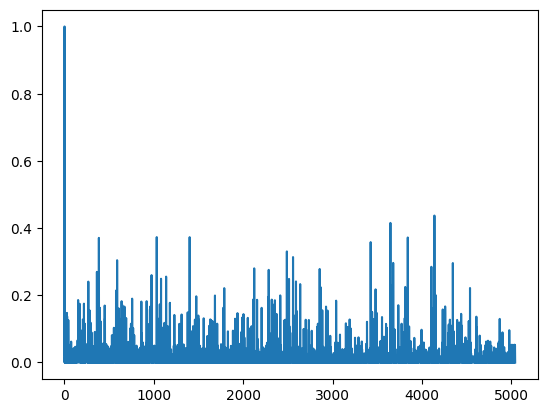

In [ ]:
import matplotlib.pyplot as plt
plt.plot(similitud)
plt.show()


### 👉 **Obtener Índices para Ordenar por Similitud Descendente**

Este código es crucial para encontrar las películas más similares. Calcula los índices que ordenarían el array `similitud` de forma descendente.

- `(- similitud)`: Primero, se niegan todos los valores en el array `similitud`. Esto convierte los valores más grandes en los más pequeños (negativamente hablando), y los más pequeños en los más grandes.
- `.argsort()`: Luego, se usa `.argsort()` en el array negado. `argsort()` devuelve los índices que ordenarían el array en orden ascendente. Al aplicarlo a los valores negados, efectivamente obtenemos los índices que ordenarían el array original en orden descendente (es decir, de la mayor similitud a la menor).

Utiliza la biblioteca `NumPy` para la manipulación y ordenación de arrays.


In [ ]:
(- similitud).argsort()

array([   3, 4139, 3647, ...,   24,   23,   20])


###  👉 **Graficar la Similitud Ordenada**

Este código genera un gráfico de línea de los valores de similitud, pero esta vez ordenados de mayor a menor.

- `(- similitud).argsort()`: Como en la celda anterior, esto obtiene los índices que ordenarían `similitud` de mayor a menor.
- `similitud[...]`: Usa esos índices para reordenar el array `similitud` en sí mismo, de modo que los valores más altos aparezcan primero.
- `plt.plot(...)`: Dibuja un gráfico de línea con estos valores de similitud ya ordenados.

Utiliza la biblioteca `matplotlib` para la visualización de datos y `NumPy` para la indexación y ordenación de arrays.


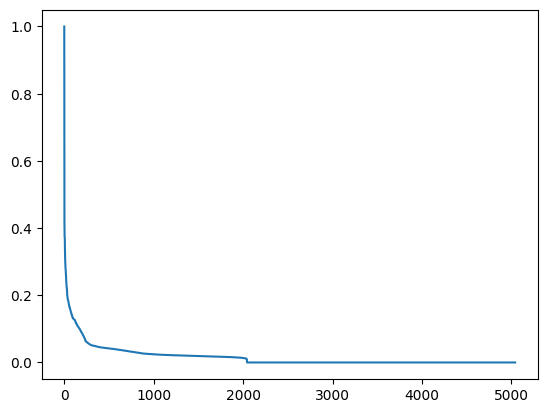

In [ ]:
plt.plot(similitud[(- similitud).argsort()])


### 👉 **Seleccionar las 10 Mejores Recomendaciones (Excluyendo la Propia Película)**

Este código utiliza los índices ordenados por similitud para obtener las 10 películas más similares, excluyendo la película original que se consultó (ya que su similitud consigo misma siempre será 1.0).

- `(- similitud).argsort()`: Obtiene los índices de las películas ordenadas por su similitud de forma descendente.
- `[1:11]`: Se realiza un 'slicing' en el array de índices. Se toma desde el índice `1` (la segunda película más similar, ya que el índice `0` corresponde a la película original) hasta el índice `10` (excluyéndolo), lo que resulta en un array de 10 índices correspondientes a las películas más recomendadas.
- `recomendacion = ...`: Almacena estos 10 índices en la variable `recomendacion`.

Utiliza la biblioteca `NumPy` para la manipulación y el 'slicing' de arrays.


In [ ]:
recomendacion =(- similitud).argsort()[1:11]


### 👉 **Mostrar los Títulos de las Películas Recomendadas**

Finalmente, este código utiliza los índices de las películas recomendadas para obtener y mostrar sus títulos correspondientes del DataFrame original.

- `df['movie_title']`: Selecciona la columna 'movie_title' del DataFrame `df`, que contiene los nombres de todas las películas.
- `.iloc[recomendacion]`: Usa el método `.iloc` (indexación basada en la posición entera) para seleccionar las filas de la columna 'movie_title' cuyos índices están presentes en el array `recomendacion`. Esto recupera los títulos de las 10 películas más similares.

Utiliza la biblioteca `pandas` para la manipulación de DataFrames y la selección de datos.

In [ ]:
df['movie_title'].iloc[recomendacion]

,movie_title
4139,AWOL-72
3647,Deadfall
1034,The One
1402,Lethal Weapon 3
3841,Police Academy
387,The Devil's Own
3426,Swelter
2489,Let's Be Cops
2558,Hot Fuzz
591,Die Hard 2
